# HDC Language Recognition: Nystrom-Approximated Spectrum Kernel vs. N-gram Baseline

Front-end for `nystrom_encoder.py`, which reimplements the minimal pieces of `NysHD` (the
AAAI'25 Nystrom-method-for-HDC paper, vendored as a submodule under `NysHD/`) needed here:
a k-mer spectrum kernel over this project's 27-character alphabet, kernel-matrix normalization
(cosine-style, `K_hat(x,x') = K(x,x')/sqrt(K(x,x)K(x',x'))`, as required for the similarity-preservation
guarantee in the paper's Theorem 1), Nystrom eigendecomposition of the normalized landmark kernel
matrix, and a sign-random-projection encoding into HD space.

Classification stays on this repo's existing architecture (`hdc_train.classify` /
`hdc_train.evaluate`): one binary class hypervector per language, built by bundling many
Nystrom-encoded training-line chunks via majority vote, classified by (optionally
precision-limited) Hamming distance -- only the *encoding* step is Nystrom-based, so results
are directly comparable to the existing N-gram baseline (`encoder.encode_text_to_hv`,
bind/permute + majority-vote bundling) at the same dimension/precision points.

**k is fixed at 3** for the Nystrom side, matching `N=3` for the N-gram baseline: the k-mer
spectrum vector has `27**k` dimensions, so k=4 is already ~530K-dim (tens of GB across all
training chunks) and k=5 is ~14M-dim (infeasible as a dense vector) -- k=3 (19,683-dim) is the
only size that comfortably fits this environment's memory.

## Setup

In [1]:
%matplotlib inline
import time

import numpy as np
import matplotlib.pyplot as plt

import hdc
import hdc_train as t
import nystrom_encoder as ne

K = 3       # k-mer size (Nystrom side)
N = 3       # n-gram size (baseline side) -- matched to K for direct comparison

test_data = {language: t.load_test_sentences(language) for language in t.LANGUAGES}

## Quick sanity check

Build the Nystrom-encoded class hypervectors at a small dimension and confirm the pipeline
behaves (landmarks sampled, kernel matrices computed + normalized, class vectors bundled)
before committing to the full sweep.

In [2]:
D_SANITY = 200

t0 = time.time()
class_hvs_sanity, encoding_matrix_sanity, landmark_features_sanity, landmark_self_kernel_sanity = (
    ne.train_class_vectors_nystrom(D_SANITY, K)
)
print(f"Built {len(class_hvs_sanity)} class hypervectors of dimension {D_SANITY} in {time.time() - t0:.1f}s")
print(f"Danish class hypervector shape: {class_hvs_sanity['dan'].shape}")
print(f"First 50 bits: {class_hvs_sanity['dan'][:50]}")

Built 10 class hypervectors of dimension 200 in 51.8s
Danish class hypervector shape: (200,)
First 50 bits: [0 0 1 1 1 0 1 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 1 1 1 0 1 0 0 0 0 0 1 0 0 1
 0 1 0 0 0 1 0 0 1 0 1 1 1]


## Baseline point: D=1024

Both methods are trained/evaluated at `D=1024` (Nystrom with `k=3`, N-gram with `N=3`) as the
common reference point for the precision sweep below.

In [3]:
D_BASELINE = 1024

# --- Nystrom ---
t0 = time.time()
class_hvs_nys, encoding_matrix_nys, landmark_features_nys, landmark_self_kernel_nys = (
    ne.train_class_vectors_nystrom(D_BASELINE, K)
)
print(f"[Nystrom] training took {time.time() - t0:.1f}s")

t0 = time.time()
baseline_accuracy_nys = ne.evaluate_nystrom(
    class_hvs_nys, encoding_matrix_nys, landmark_features_nys, landmark_self_kernel_nys,
    K, D_BASELINE, test_data
)
print(f"[Nystrom] evaluation took {time.time() - t0:.1f}s")
print(f"D={D_BASELINE} k={K} (Nystrom) -> accuracy={baseline_accuracy_nys:.4f}")

# --- N-gram baseline ---
t0 = time.time()
item_memory = hdc.generate_item_memory(t.ALPHABET, D_BASELINE, seed=42)
class_hvs_ngram = t.train_class_vectors(item_memory, N, D_BASELINE)
print(f"[N-gram] training took {time.time() - t0:.1f}s")

t0 = time.time()
baseline_accuracy_ngram = t.evaluate(item_memory, class_hvs_ngram, N, D_BASELINE, test_data)
print(f"[N-gram] evaluation took {time.time() - t0:.1f}s")
print(f"D={D_BASELINE} N={N} (N-gram baseline) -> accuracy={baseline_accuracy_ngram:.4f}")

[Nystrom] training took 57.3s


[Nystrom] evaluation took 6.6s
D=1024 k=3 (Nystrom) -> accuracy=0.9565


[N-gram] training took 75.9s


[N-gram] evaluation took 10.5s
D=1024 N=3 (N-gram baseline) -> accuracy=0.9405


## Precision sweep

Per-block Hamming-distance precision in `{10, 8, 6}` (block size fixed at 16 bits), at the
fixed `D=1024` point for both methods. Class hypervectors don't depend on precision -- only
the classification-time distance metric does -- so this reuses the class vectors built above
and only re-evaluates with different `precision` values, no retraining.

In [4]:
precisions = [10, 8, 6]

accuracy_by_precision_nys = {16: baseline_accuracy_nys}
accuracy_by_precision_ngram = {16: baseline_accuracy_ngram}

for precision in precisions:
    t0 = time.time()
    acc_nys = ne.evaluate_nystrom(
        class_hvs_nys, encoding_matrix_nys, landmark_features_nys, landmark_self_kernel_nys,
        K, D_BASELINE, test_data, precision=precision
    )
    accuracy_by_precision_nys[precision] = acc_nys
    print(f"[Nystrom] D={D_BASELINE} k={K} precision={precision:2d} -> accuracy={acc_nys:.4f}  ({time.time() - t0:.1f}s)")

    t0 = time.time()
    acc_ngram = t.evaluate(item_memory, class_hvs_ngram, N, D_BASELINE, test_data, precision=precision)
    accuracy_by_precision_ngram[precision] = acc_ngram
    print(f"[N-gram]  D={D_BASELINE} N={N} precision={precision:2d} -> accuracy={acc_ngram:.4f}  ({time.time() - t0:.1f}s)")

[Nystrom] D=1024 k=3 precision=10 -> accuracy=0.9556  (8.0s)


[N-gram]  D=1024 N=3 precision=10 -> accuracy=0.9406  (11.1s)


[Nystrom] D=1024 k=3 precision= 8 -> accuracy=0.9536  (7.6s)


[N-gram]  D=1024 N=3 precision= 8 -> accuracy=0.9344  (11.1s)


[Nystrom] D=1024 k=3 precision= 6 -> accuracy=0.9321  (7.8s)


[N-gram]  D=1024 N=3 precision= 6 -> accuracy=0.9065  (11.0s)


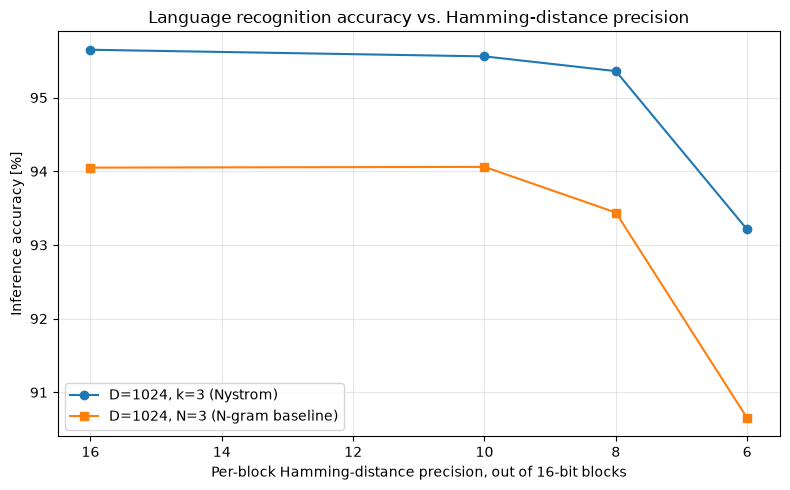

In [5]:
xs = sorted(accuracy_by_precision_nys, reverse=True)
ys_nys = [accuracy_by_precision_nys[x] * 100 for x in xs]
ys_ngram = [accuracy_by_precision_ngram[x] * 100 for x in xs]

plt.figure(figsize=(8, 5))
plt.plot(xs, ys_nys, marker='o', label=f"D={D_BASELINE}, k={K} (Nystrom)")
plt.plot(xs, ys_ngram, marker='s', label=f"D={D_BASELINE}, N={N} (N-gram baseline)")
plt.gca().invert_xaxis()
plt.xlabel("Per-block Hamming-distance precision, out of 16-bit blocks")
plt.ylabel("Inference accuracy [%]")
plt.title("Language recognition accuracy vs. Hamming-distance precision")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("accuracy_vs_hamming_precision_comparison.png", dpi=150)
plt.show()

## Dimension sweep

Vector dimension in `{1024, 512, 128, 64}`, exact Hamming distance (`precision=None`) for both
methods -- tests the effect of shrinking the hypervector itself, independent of the
precision-clamp sweep above. Each dimension needs its own encoding (the Nystrom random
projection and the N-gram item memory both depend on `dimension`), so both are rebuilt per
point.

In [6]:
dimensions = [1024, 512, 128, 64]

accuracy_by_dimension_nys = {1024: baseline_accuracy_nys}
accuracy_by_dimension_ngram = {1024: baseline_accuracy_ngram}

for dimension in dimensions:
    if dimension == D_BASELINE:
        continue

    t0 = time.time()
    class_hvs_d, encoding_matrix_d, landmark_features_d, landmark_self_kernel_d = (
        ne.train_class_vectors_nystrom(dimension, K)
    )
    acc_nys = ne.evaluate_nystrom(
        class_hvs_d, encoding_matrix_d, landmark_features_d, landmark_self_kernel_d,
        K, dimension, test_data
    )
    accuracy_by_dimension_nys[dimension] = acc_nys
    print(f"[Nystrom] D={dimension:5d} k={K} -> accuracy={acc_nys:.4f}  ({time.time() - t0:.1f}s)")

    t0 = time.time()
    item_memory_d = hdc.generate_item_memory(t.ALPHABET, dimension, seed=42)
    class_hvs_ngram_d = t.train_class_vectors(item_memory_d, N, dimension)
    acc_ngram = t.evaluate(item_memory_d, class_hvs_ngram_d, N, dimension, test_data)
    accuracy_by_dimension_ngram[dimension] = acc_ngram
    print(f"[N-gram]  D={dimension:5d} N={N} -> accuracy={acc_ngram:.4f}  ({time.time() - t0:.1f}s)")

[Nystrom] D=  512 k=3 -> accuracy=0.9209  (90.1s)


[N-gram]  D=  512 N=3 -> accuracy=0.9001  (84.1s)


[Nystrom] D=  128 k=3 -> accuracy=0.7389  (79.5s)


[N-gram]  D=  128 N=3 -> accuracy=0.6890  (77.7s)


[Nystrom] D=   64 k=3 -> accuracy=0.5767  (77.0s)


[N-gram]  D=   64 N=3 -> accuracy=0.5489  (74.7s)


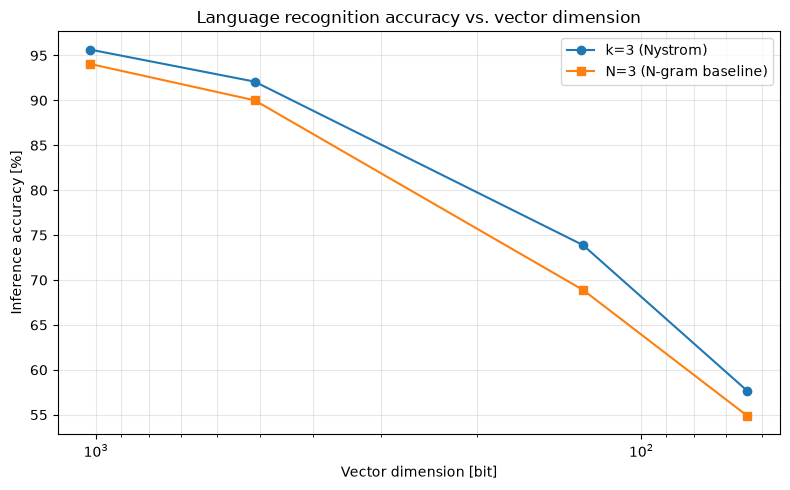

In [7]:
xs = sorted(accuracy_by_dimension_nys, reverse=True)
ys_nys = [accuracy_by_dimension_nys[x] * 100 for x in xs]
ys_ngram = [accuracy_by_dimension_ngram[x] * 100 for x in xs]

plt.figure(figsize=(8, 5))
plt.plot(xs, ys_nys, marker='o', label=f"k={K} (Nystrom)")
plt.plot(xs, ys_ngram, marker='s', label=f"N={N} (N-gram baseline)")
plt.gca().invert_xaxis()
plt.xscale('log')
plt.xlabel("Vector dimension [bit]")
plt.ylabel("Inference accuracy [%]")
plt.title("Language recognition accuracy vs. vector dimension")
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig("accuracy_vs_dimension_comparison.png", dpi=150)
plt.show()

## k-sweep: Nystrom accuracy vs. dimension, for k in {3, 4}

Repeats the dimension sweep above (`D` in `{1024, 512, 128, 64}`) for `k=3` and `k=4`, to see
how k-mer size trades off against dimension.

**k=5 is excluded entirely from this sweep** -- not a stretch cell, not attempted here. The
k-mer spectrum vector has `27**k` dimensions, so k=5 is `27**5 = 14,348,907`-dim. Even just the
*landmark* feature matrix (which must be fully resident at once to compute
`landmark_features @ landmark_features.T` -- unlike per-language chunk processing, this side
can't be batched away) would need ~17.2GB at only 300 landmarks and float32, already over this
machine's ~17GB RAM budget before touching any per-language training data. Shrinking landmarks
enough to fit (e.g. to ~50) would put the approximation below the "300 minimum" floor this
codebase (and NysHD's own recipe) treats as necessary for a meaningful Nystrom approximation,
which would confound any k=5-vs-k=3/4 comparison with a "too few landmarks" effect rather than a
clean k-only comparison. No scipy/sklearn is installed here for a sparse-matrix fallback either.

**k=4 is feasible, with two changes**: `dtype=np.float32` (halves memory) and
`batch_size=1000` (caps peak memory per language to `batch_size x 27**k` instead of
`num_chunks x 27**k`, since a full language's ~10,000-chunk spectrum matrix at k=4 would be
~42.6GB at float64 or ~21.3GB at float32 alone -- both exceed available RAM without batching).

**Both k=3 and k=4 use the same `dtype=np.float32, batch_size=1000`** in this sweep (not
`float64`/unbatched for k=3) -- dtype and batching are a memory-management choice, not a
property of k itself, and letting them differ between the two k values would confound the
comparison (a k=4-worse-than-k=3 result would then be ambiguous between "k=4 genuinely worse"
and "float32 rounding hurt k=4 more"). float32 has already been confirmed to agree with float64
to within `1e-9` on this project's kernel values (see verification checks run during
implementation), so this costs no meaningful accuracy while keeping k=3 and k=4 differing in
exactly one variable.

**`num_landmark=500`, not the ~2000 default, for this sweep** (and reused below for the
stratified-landmark comparison and the ensembling section). The ~2000 default comes from
`max(2% of pooled chunks, 300)` -- a generic heuristic carried over directly from NysHD's own
paper code, not something tuned for this task. Measured directly: k=4 training at the default
~2000 landmarks took ~14 minutes per (D,k) point (~56 minutes just for k=4's 4 dimensions), vs.
~5.5 minutes at `num_landmark=500` -- a large speedup for a sweep whose point is to compare k
values and dimensions, not landmark count (that's the next section's job). 500 is still well
above the "300 minimum" floor.

In [ ]:
k_values = [3, 4]
K_SWEEP_DTYPE = np.float32
K_SWEEP_BATCH_SIZE = 1000
K_SWEEP_NUM_LANDMARK = 500

accuracy_by_k = {k: {} for k in k_values}

for k in k_values:
    for dimension in dimensions:
        t0 = time.time()
        class_hvs_k, encoding_matrix_k, landmark_features_k, landmark_self_kernel_k = (
            ne.train_class_vectors_nystrom(dimension, k, num_landmark=K_SWEEP_NUM_LANDMARK,
                                            dtype=K_SWEEP_DTYPE, batch_size=K_SWEEP_BATCH_SIZE)
        )
        acc_k = ne.evaluate_nystrom(
            class_hvs_k, encoding_matrix_k, landmark_features_k, landmark_self_kernel_k,
            k, dimension, test_data, dtype=K_SWEEP_DTYPE, batch_size=K_SWEEP_BATCH_SIZE
        )
        accuracy_by_k[k][dimension] = acc_k
        print(f"D={dimension:5d} k={k} -> accuracy={acc_k:.4f}  ({time.time() - t0:.1f}s)")

In [ ]:
plt.figure(figsize=(8, 5))
for k in k_values:
    xs = sorted(accuracy_by_k[k], reverse=True)
    ys = [accuracy_by_k[k][x] * 100 for x in xs]
    plt.plot(xs, ys, marker='o', label=f"k={k}")

plt.gca().invert_xaxis()
plt.xscale('log')
plt.xlabel("Vector dimension [bit]")
plt.ylabel("Inference accuracy [%]")
plt.title("Nystrom accuracy vs. vector dimension, by k-mer size")
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig("accuracy_vs_dimension_by_k.png", dpi=150)
plt.show()

## Stratified vs. unstratified landmark sampling

Today's `sample_landmarks` draws landmarks uniformly at random from ALL 10 languages' chunks
pooled together (`chunks_by_language`'s values flattened into one list) -- it happens to end up
roughly balanced across languages only because each language contributes a near-equal chunk
count (~10,000-10,011), not by design. `sample_landmarks_stratified` makes that balance an
explicit guarantee: it allocates `num_landmark // 10` landmarks to each language (plus a
deterministic remainder split), sampled from that language's own chunks.

Compares both strategies at `k=3`, `num_landmark=500` (same reduced count as the k-sweep above,
for consistency and speed) across the same `D` grid, same `seed` each time so only the
sampling strategy differs. Reports both aggregate accuracy and **per-language** accuracy (via
`return_per_language=True`) -- stratification's expected benefit (protecting under-represented
languages from being poorly approximated) is a per-language claim that an aggregate number can
wash out, especially since today's per-language chunk counts are already near-equal.

In [ ]:
K_STRATIFY = 3
STRATIFY_NUM_LANDMARK = 500

accuracy_unstratified = {}
accuracy_stratified = {}
per_language_unstratified = {}
per_language_stratified = {}

for dimension in dimensions:
    t0 = time.time()
    class_hvs_u, enc_u, lf_u, lsk_u = ne.train_class_vectors_nystrom(
        dimension, K_STRATIFY, num_landmark=STRATIFY_NUM_LANDMARK)
    acc_u, per_lang_u = ne.evaluate_nystrom(class_hvs_u, enc_u, lf_u, lsk_u, K_STRATIFY, dimension,
                                             test_data, return_per_language=True)
    accuracy_unstratified[dimension] = acc_u
    per_language_unstratified[dimension] = per_lang_u
    print(f"[unstratified] D={dimension:5d} k={K_STRATIFY} -> accuracy={acc_u:.4f}  ({time.time() - t0:.1f}s)")

    t0 = time.time()
    class_hvs_s, enc_s, lf_s, lsk_s = ne.train_class_vectors_nystrom(
        dimension, K_STRATIFY, num_landmark=STRATIFY_NUM_LANDMARK,
        landmark_sampler=ne.sample_landmarks_stratified)
    acc_s, per_lang_s = ne.evaluate_nystrom(class_hvs_s, enc_s, lf_s, lsk_s, K_STRATIFY, dimension,
                                             test_data, return_per_language=True)
    accuracy_stratified[dimension] = acc_s
    per_language_stratified[dimension] = per_lang_s
    print(f"[stratified]   D={dimension:5d} k={K_STRATIFY} -> accuracy={acc_s:.4f}  ({time.time() - t0:.1f}s)")

In [ ]:
xs = sorted(accuracy_unstratified, reverse=True)
ys_u = [accuracy_unstratified[x] * 100 for x in xs]
ys_s = [accuracy_stratified[x] * 100 for x in xs]

plt.figure(figsize=(8, 5))
plt.plot(xs, ys_u, marker='o', label="unstratified (pooled random)")
plt.plot(xs, ys_s, marker='s', label="stratified (equal per language)")
plt.gca().invert_xaxis()
plt.xscale('log')
plt.xlabel("Vector dimension [bit]")
plt.ylabel("Inference accuracy [%]")
plt.title(f"Landmark sampling strategy vs. accuracy (k={K_STRATIFY})")
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig("accuracy_vs_dimension_stratified_comparison.png", dpi=150)
plt.show()

print(f"\nPer-language accuracy at D={dimensions[0]}:")
print(f"{'language':10s} {'unstratified':>14s} {'stratified':>12s}")
for language in t.LANGUAGES:
    print(f"{language:10s} {per_language_unstratified[dimensions[0]][language]:>14.4f} "
          f"{per_language_stratified[dimensions[0]][language]:>12.4f}")

## Landmark-count sweep at fixed D=1024

Growing the number of landmarks increases *training*-time cost (a bigger
`landmark_kernel_matrix` to eigendecompose, bigger chunk-vs-landmark kernel matrices per
language) but does **not** change *inference*-time classification cost: `encoding_matrix`
always has shape `(D, num_landmark)`, so once D is fixed, Hamming-distance classification
always runs on D-length vectors regardless of how many landmarks were used to build the
encoding. (The kernel-vs-landmark computation at test time does grow mildly with
`num_landmark` -- linearly, via a `(1, num_landmark) @ (num_landmark, D)` matmul per test
sentence -- but this is dominated by k-mer spectrum extraction, which is constant in
`num_landmark`, so it should be near-invisible next to training's cost growth.)

Sweeps `num_landmark` in `{500, 800, 1000, 2000}` at fixed `D=1024`, `k=3` (matching the
primary comparison point used throughout this notebook). Times both training and evaluation
at each point to check this cost-model claim with actual measurements rather than just the
architectural argument.

In [ ]:
num_landmark_values = [500, 800, 1000, 2000]
D_FIXED = 1024
K_LANDMARK_SWEEP = 3

accuracy_by_num_landmark = {}
train_time_by_num_landmark = {}
eval_time_by_num_landmark = {}

for num_landmark in num_landmark_values:
    t0 = time.time()
    class_hvs_nl, encoding_matrix_nl, landmark_features_nl, landmark_self_kernel_nl = (
        ne.train_class_vectors_nystrom(D_FIXED, K_LANDMARK_SWEEP, num_landmark=num_landmark)
    )
    train_time_by_num_landmark[num_landmark] = time.time() - t0

    t0 = time.time()
    acc = ne.evaluate_nystrom(class_hvs_nl, encoding_matrix_nl, landmark_features_nl,
                               landmark_self_kernel_nl, K_LANDMARK_SWEEP, D_FIXED, test_data)
    eval_time_by_num_landmark[num_landmark] = time.time() - t0

    accuracy_by_num_landmark[num_landmark] = acc
    print(f"num_landmark={num_landmark:5d} D={D_FIXED} k={K_LANDMARK_SWEEP} -> accuracy={acc:.4f}  "
          f"(train {train_time_by_num_landmark[num_landmark]:.1f}s, "
          f"eval {eval_time_by_num_landmark[num_landmark]:.1f}s)")

In [ ]:
xs = sorted(accuracy_by_num_landmark)
ys = [accuracy_by_num_landmark[x] * 100 for x in xs]

plt.figure(figsize=(8, 5))
plt.plot(xs, ys, marker='o')
plt.xlabel("Number of landmarks")
plt.ylabel("Inference accuracy [%]")
plt.title(f"Accuracy vs. landmark count (D={D_FIXED}, k={K_LANDMARK_SWEEP})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("accuracy_vs_num_landmark.png", dpi=150)
plt.show()

In [ ]:
xs = sorted(train_time_by_num_landmark)
train_ys = [train_time_by_num_landmark[x] for x in xs]
eval_ys = [eval_time_by_num_landmark[x] for x in xs]

plt.figure(figsize=(8, 5))
plt.plot(xs, train_ys, marker='o', label="training time")
plt.plot(xs, eval_ys, marker='s', label="evaluation time")
plt.xlabel("Number of landmarks")
plt.ylabel("Time [s]")
plt.title(f"Training vs. evaluation time by landmark count (D={D_FIXED}, k={K_LANDMARK_SWEEP})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("time_vs_num_landmark.png", dpi=150)
plt.show()

## Ensembling independent small-D encoders

**What this tests**: given a fixed total "bit budget" spent at classification time, is it
better spent as *one* wide hypervector, or as *several* independent narrower hypervectors
whose classification decisions get majority-voted? A single D=256 encoder is a noisier
classifier than a single D=1024 one -- fewer bits carry less information about the
kernel-similarity structure once sign-random-projected. But several independent D=256
encoders (different random projections -> different, hopefully semi-independent error
patterns) might, combined by majority vote, recover accuracy close to the single D=1024
encoder -- the same logic as an ensemble of weak classifiers approaching a strong one.

The practical payoff if this holds: a hardware implementation could use narrower
per-comparison hypervectors (cheaper Hamming-distance hardware, directly relevant to the
16-bit block/precision constraint used elsewhere in this notebook) at the cost of repeating
the comparison a few times, instead of needing one wide comparison.

Builds `num_encoders` independent `D_small = 1024 // num_encoders`-dimension encoders, all
reusing the *same* landmark eigendecomposition (the expensive step) -- only the cheap
random-projection step repeats per encoder, each with a different seed.

Uses `num_landmark=500` (matching the k-sweep/stratified-comparison sections above) for all
points, **including a freshly-computed `num_encoders=1` reference point at the same
`num_landmark=500`** -- NOT the earlier `baseline_accuracy_nys`, which was computed at the
default `num_landmark` (~2000). Reusing that earlier number here would confound ensemble size
with landmark count (a real difference between `num_encoders=1` and `num_encoders=2/4` could
then be due to fewer landmarks, not fewer/more encoders). Recomputing a matched baseline keeps
`num_landmark` fixed as the one thing held constant across every point in this comparison.

In [ ]:
TOTAL_DIMENSION = 1024
K_ENSEMBLE = 3
ENSEMBLE_NUM_LANDMARK = 500

accuracy_by_num_encoders = {}

# num_encoders=1 is just a single full-width encoder -- reuse train_class_vectors_nystrom/
# evaluate_nystrom directly, at the SAME num_landmark as the num_encoders=2/4 points below,
# so num_landmark is held constant and only ensemble size varies across this comparison.
t0 = time.time()
class_hvs_1, enc_1, lf_1, lsk_1 = ne.train_class_vectors_nystrom(
    TOTAL_DIMENSION, K_ENSEMBLE, num_landmark=ENSEMBLE_NUM_LANDMARK)
acc_1 = ne.evaluate_nystrom(class_hvs_1, enc_1, lf_1, lsk_1, K_ENSEMBLE, TOTAL_DIMENSION, test_data)
accuracy_by_num_encoders[1] = acc_1
print(f"num_encoders=1 (D_small={TOTAL_DIMENSION}) -> accuracy={acc_1:.4f}  ({time.time() - t0:.1f}s)")

num_encoders_values = [2, 4]
for num_encoders in num_encoders_values:
    t0 = time.time()
    encoders = ne.train_class_vectors_nystrom_ensemble(
        TOTAL_DIMENSION, num_encoders, K_ENSEMBLE, num_landmark=ENSEMBLE_NUM_LANDMARK)
    encoder_dimension = TOTAL_DIMENSION // num_encoders
    acc = ne.evaluate_nystrom_ensemble(encoders, K_ENSEMBLE, encoder_dimension, test_data)
    accuracy_by_num_encoders[num_encoders] = acc
    print(f"num_encoders={num_encoders} (D_small={encoder_dimension}) -> accuracy={acc:.4f}  ({time.time() - t0:.1f}s)")

In [ ]:
xs = sorted(accuracy_by_num_encoders)
ys = [accuracy_by_num_encoders[x] * 100 for x in xs]
labels = [f"{x}x D={TOTAL_DIMENSION // x}" for x in xs]

plt.figure(figsize=(8, 5))
plt.plot(xs, ys, marker='o')
for x, y, label in zip(xs, ys, labels):
    plt.annotate(label, (x, y), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=8)
plt.xticks(xs)
plt.xlabel("Number of independent encoders (ensemble size)")
plt.ylabel("Inference accuracy [%]")
plt.title(f"Ensembling small-D encoders vs. single D={TOTAL_DIMENSION} baseline")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("accuracy_vs_ensemble_size.png", dpi=150)
plt.show()